## 1. Data Loading & Sanity Checks

In [1]:
# ============================================================
# CELL 1 — IMPORTS & DATA LOADING
# ============================================================
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ---------- Paths ----------
DATA_DIR = "data_output"
TRAIN_PATH = os.path.join(DATA_DIR, "2_data_preprocessed_tree_train.csv")
TEST_PATH = os.path.join(DATA_DIR, "2_data_preprocessed_tree_test.csv")

TARGET_COL = "Khoảng giá"

# ---------- Load ----------
df_train = pd.read_csv(TRAIN_PATH)
df_test = pd.read_csv(TEST_PATH)

print(f"Train shape : {df_train.shape}")
print(f"Test  shape : {df_test.shape}")

# ---------- Assertions ----------
assert df_train.shape[0] > 0, "Train set is empty"
assert df_test.shape[0] > 0, "Test set is empty"
assert TARGET_COL in df_train.columns, f"Target '{TARGET_COL}' not found in train"

Train shape : (4645, 26)
Test  shape : (1164, 26)


## 2. Missing Value Report

In [2]:
# ============================================================
# CELL 2 — MISSING VALUE REPORT
# ============================================================
def missing_value_report(df_train: pd.DataFrame, df_test: pd.DataFrame) -> pd.DataFrame:
    """Return a side-by-side missing-value summary for train and test."""
    report = pd.DataFrame({
        "Train Missing":   df_train.isnull().sum(),
        "Train Rate (%)":  (df_train.isnull().mean() * 100).round(2),
        "Test Missing":    df_test.isnull().sum(),
        "Test Rate (%)":   (df_test.isnull().mean() * 100).round(2),
    })
    mask = (report["Train Missing"] > 0) | (report["Test Missing"] > 0)
    return report[mask]


missing_report = missing_value_report(df_train, df_test)

if missing_report.empty:
    print("No missing values in either split.")
else:
    print(missing_report.to_string())

                    Train Missing  Train Rate (%)  Test Missing  Test Rate (%)
Dien_Tich_Lo                  961           20.69           226          19.42
Ty_Le_Giao_Thong              967           20.82           229          19.67
Ty_Le_Cong_Cong_CX            967           20.82           229          19.67
Ty_Le_Khac                    967           20.82           229          19.67
Ty_Le_Dat_O                   967           20.82           229          19.67


## 3. Boxplots — Numeric Columns

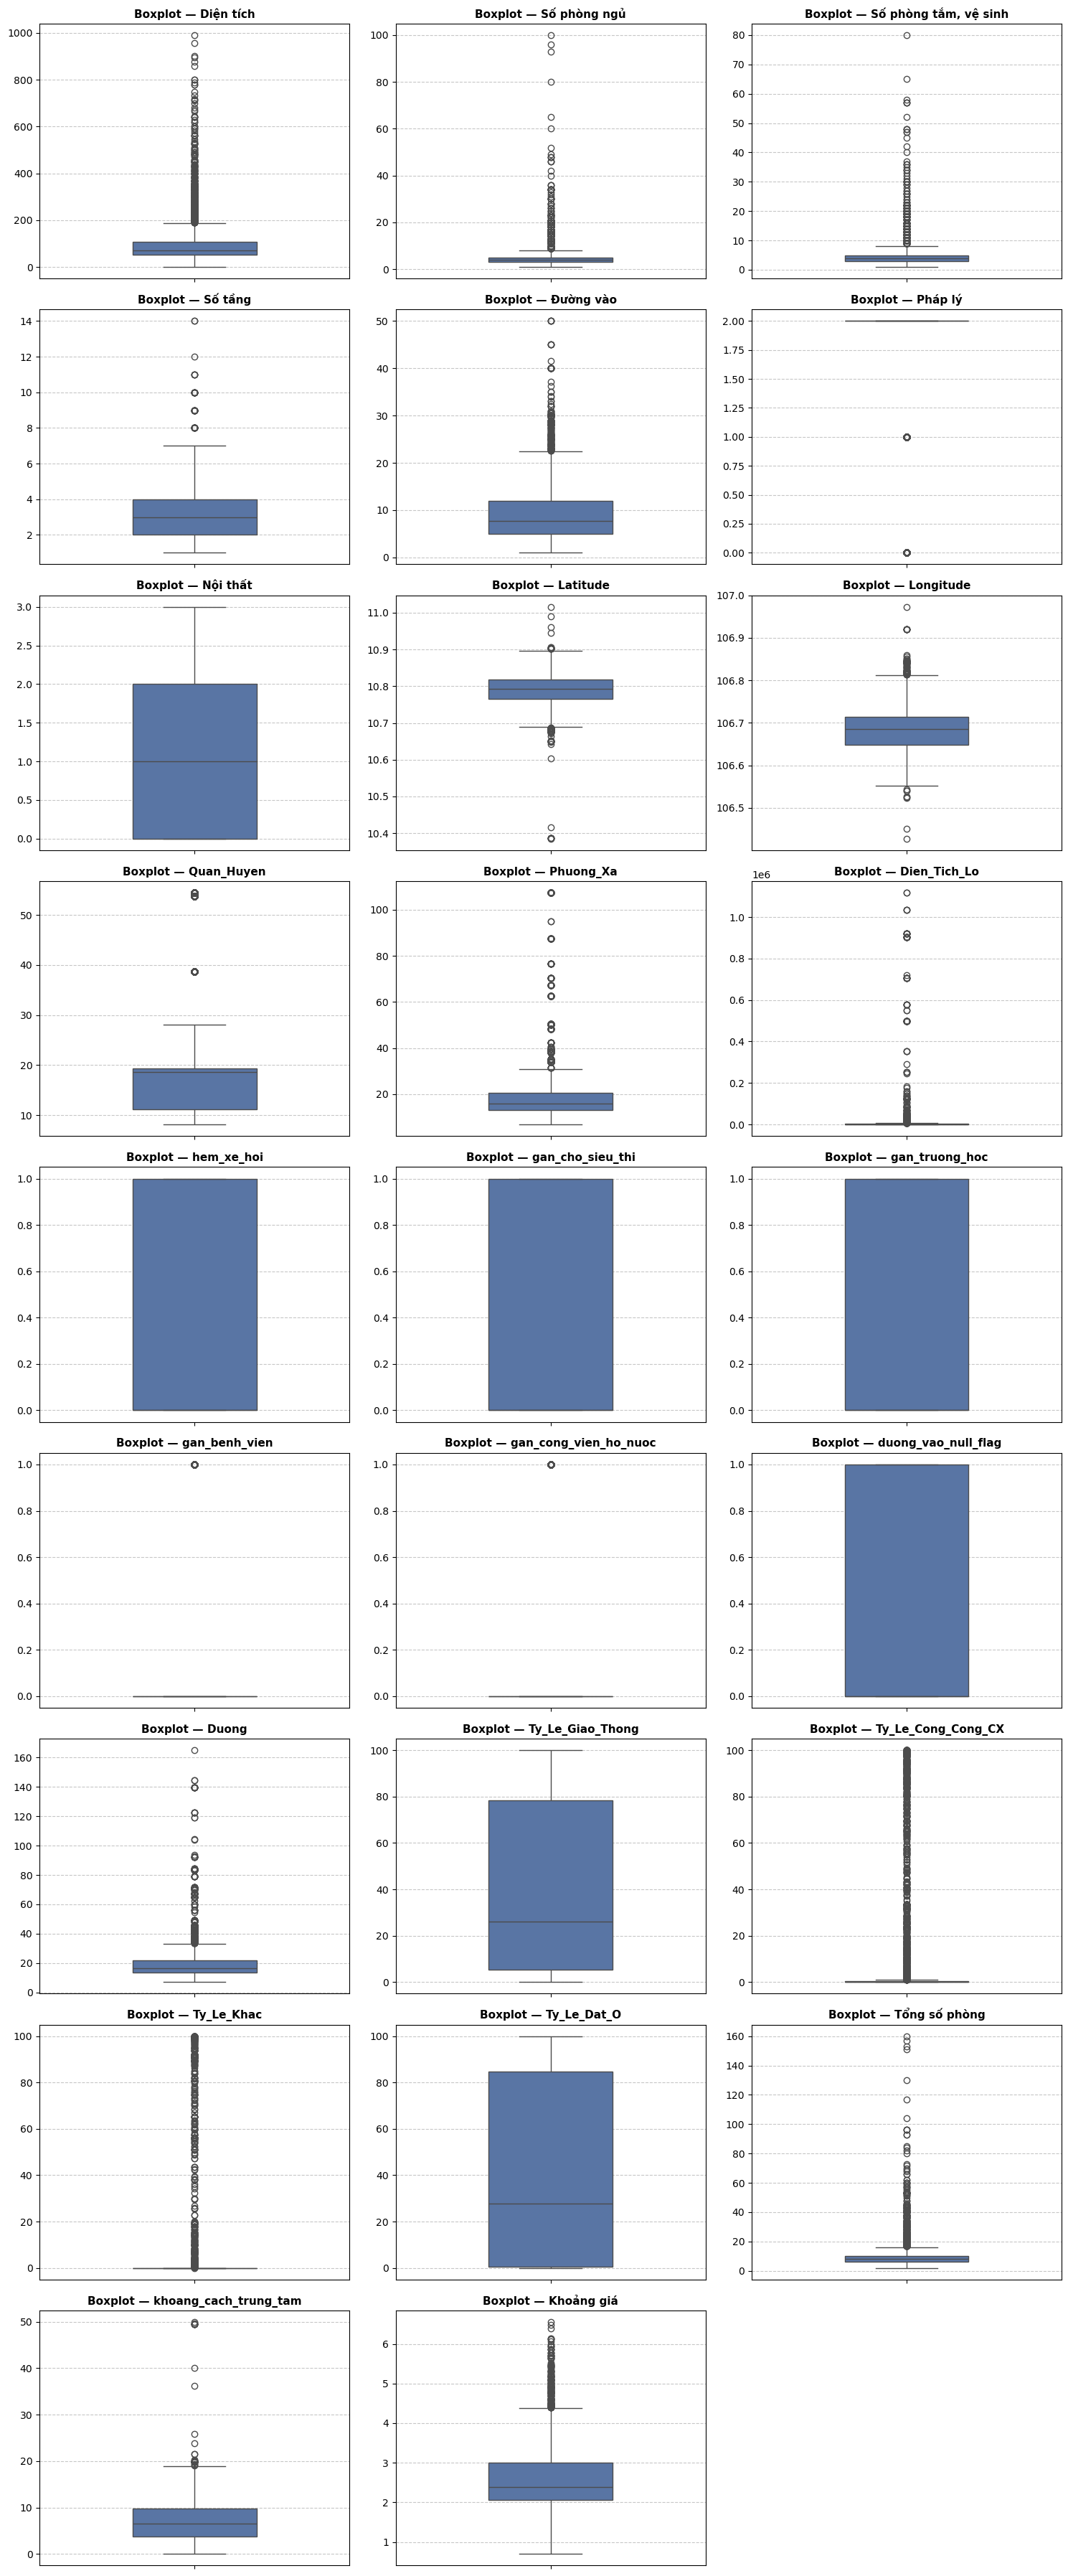

In [3]:
# ============================================================
# CELL 3 — BOXPLOTS FOR NUMERIC COLUMNS (TRAIN)
# ============================================================
def plot_numeric_boxplots(df: pd.DataFrame, n_cols: int = 3) -> None:
    num_cols = df.select_dtypes(include="number").columns.tolist()
    if not num_cols:
        print("No numeric columns found.")
        return

    n_rows = int(np.ceil(len(num_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    axes = axes.flatten()

    for i, col in enumerate(num_cols):
        sns.boxplot(data=df, y=col, ax=axes[i], color="#4C72B0", width=0.4)
        axes[i].set_title(f"Boxplot — {col}", fontsize=11, fontweight="bold")
        axes[i].set_ylabel("")
        axes[i].grid(axis="y", linestyle="--", alpha=0.7)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


plot_numeric_boxplots(df_train)

## 4. Target Distribution (IEEE Panel)

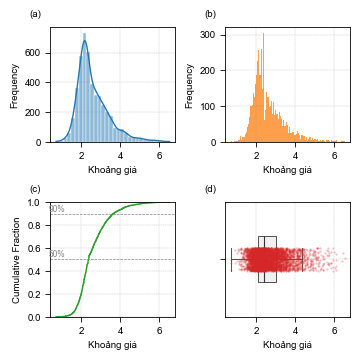

In [ ]:
# ============================================================
# CELL 4 — TARGET DISTRIBUTION (IEEE-STYLE 2×2 PANEL)
# ============================================================
plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial"],
    "font.size":        7,
    "axes.labelsize":   7,
    "xtick.labelsize":  7,
    "ytick.labelsize":  7,
    "legend.fontsize":  7,
    "axes.linewidth":   0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "lines.linewidth":  1.0,
})

target_data = pd.to_numeric(df_train[TARGET_COL], errors="coerce").dropna()

assert len(target_data) > 0, "Target column has no valid numeric values"

COLOR_BLUE   = "#1f77b4"
COLOR_ORANGE = "#ff7f0e"
COLOR_GREEN  = "#2ca02c"
COLOR_BOX_BG = "#f0f0f0"
COLOR_RED    = "#d62728"

fig, axes = plt.subplots(2, 2, figsize=(3.5, 3.5))
panel_labels = ["(a)", "(b)", "(c)", "(d)"]

sns.histplot(target_data, kde=True, ax=axes[0, 0], color=COLOR_BLUE,
             edgecolor="white", linewidth=0.3, bins=30)
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].set_xlabel(TARGET_COL)

sns.histplot(target_data, ax=axes[0, 1], color=COLOR_ORANGE, edgecolor="none", bins=100)
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_xlabel(TARGET_COL)

sns.ecdfplot(target_data, ax=axes[1, 0], color=COLOR_GREEN)
for pct, label in [(0.5, "50%"), (0.9, "90%")]:
    axes[1, 0].axhline(pct, color="gray", linestyle="--", linewidth=0.5)
    axes[1, 0].text(target_data.max() * 0.05, pct + 0.02, label, color="gray", fontsize=6)
axes[1, 0].set_ylabel("Cumulative Fraction")
axes[1, 0].set_xlabel(TARGET_COL)

sns.boxplot(
    x=target_data, ax=axes[1, 1], color=COLOR_BOX_BG, showfliers=False, width=0.4,
    boxprops=dict(edgecolor="#333333", linewidth=0.6),
    whiskerprops=dict(color="#333333", linewidth=0.6),
    capprops=dict(color="#333333", linewidth=0.6),
    medianprops=dict(color="#333333", linewidth=0.8),
)
sns.stripplot(x=target_data, ax=axes[1, 1], color=COLOR_RED, alpha=0.3, size=1.5, jitter=True)
axes[1, 1].set_xlabel(TARGET_COL)

for i, ax in enumerate(axes.flatten()):
    ax.grid(axis="both", linestyle="--", linewidth=0.3, alpha=0.5, color="gray")
    ax.annotate(panel_labels[i], xy=(0, 1), xycoords="axes fraction",
                xytext=(-15, 6), textcoords="offset points",
                fontsize=7, ha="left", va="bottom")

plt.tight_layout(pad=0.5, w_pad=1.0, h_pad=1.0)
#plt.savefig("target_distribution_ieee.png", dpi=300, format="png", bbox_inches="tight")
plt.show()

## 5. Correlation Heatmap (Pearson & Spearman)

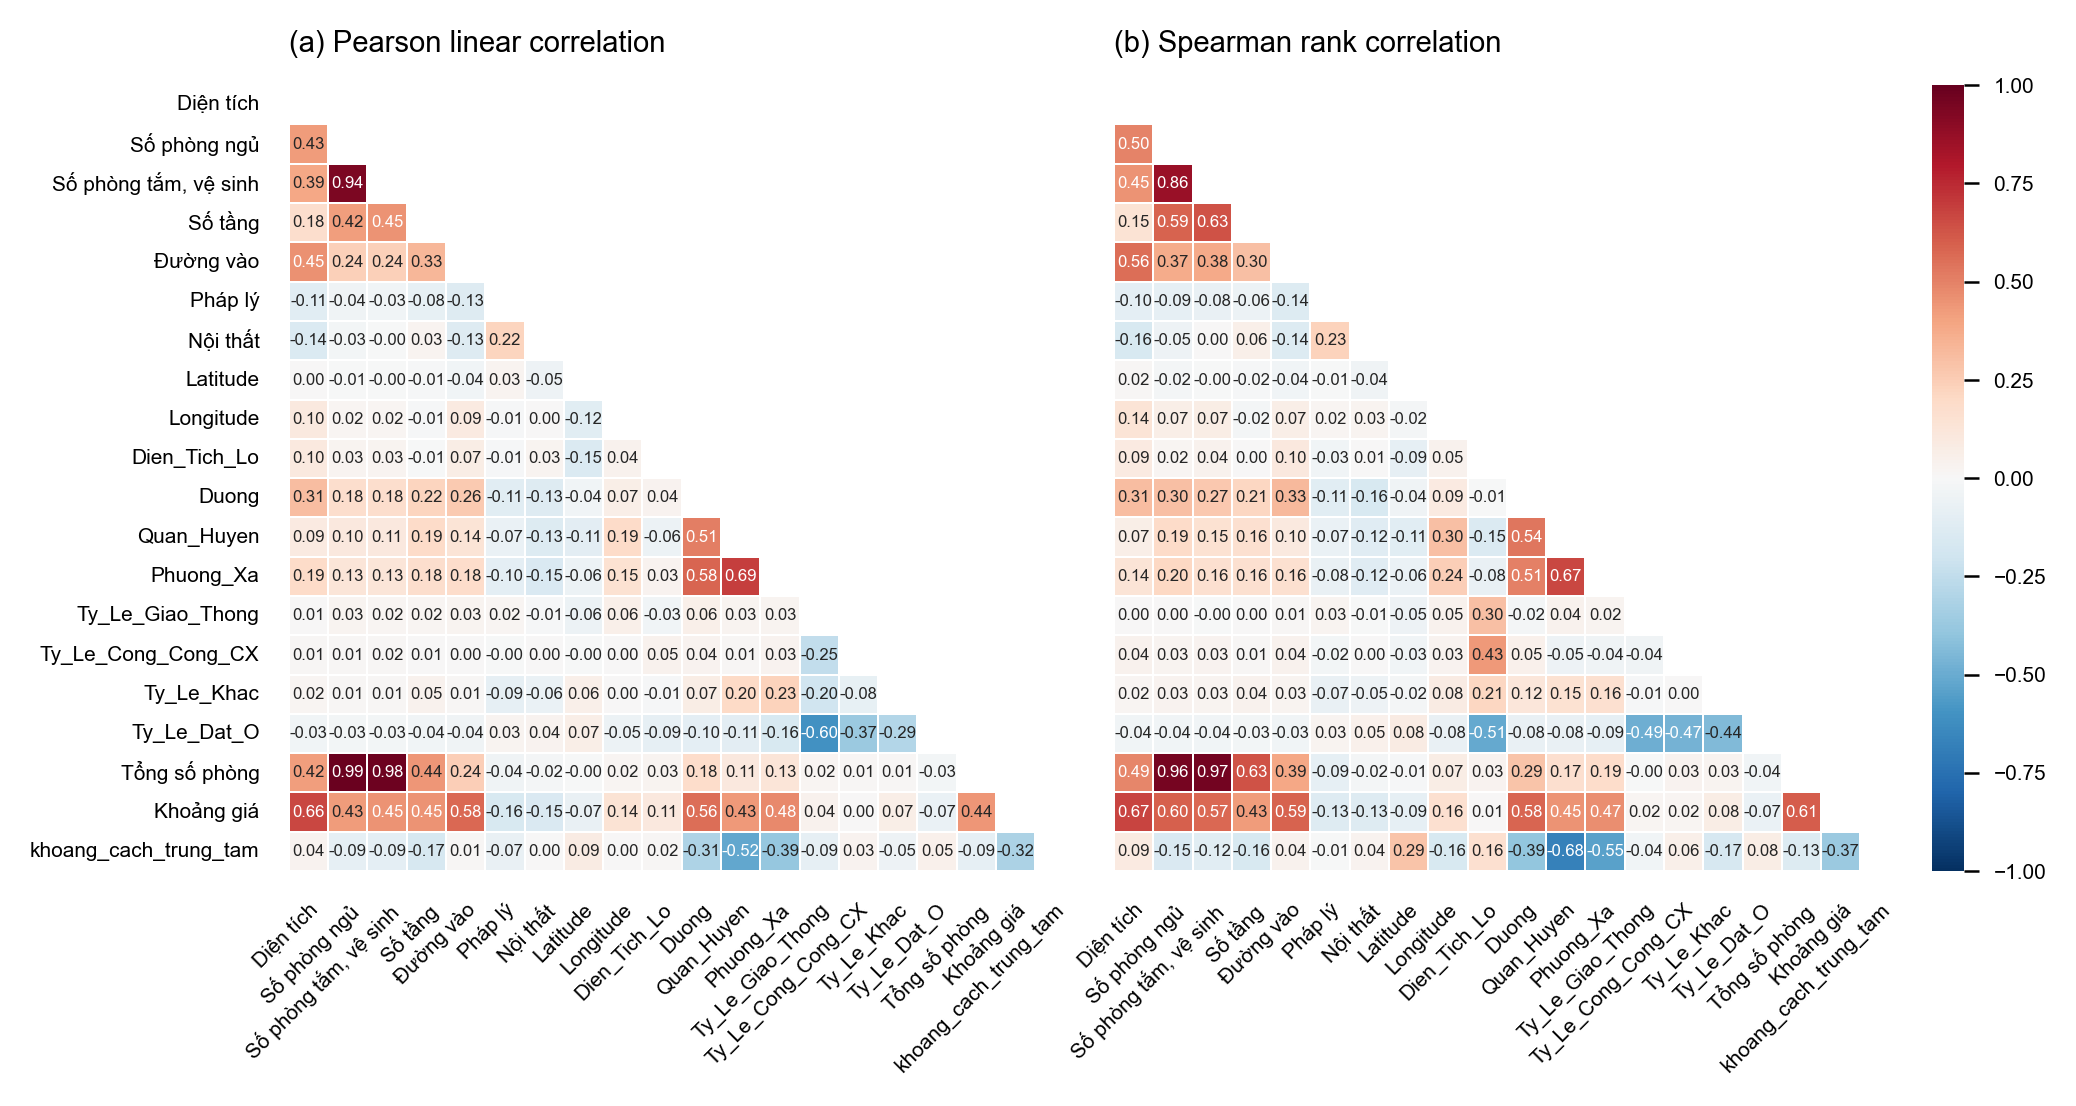

In [ ]:
# ============================================================
# CELL 5 — CORRELATION HEATMAP (PEARSON & SPEARMAN)
# ============================================================
CORR_COLS = [
    "Diện tích", "Số phòng ngủ", "Số phòng tắm, vệ sinh", "Số tầng",
    "Đường vào", "Pháp lý", "Nội thất", "Latitude", "Longitude",
    "Dien_Tich_Lo", "Duong", "Quan_Huyen", "Phuong_Xa",
    "Ty_Le_Giao_Thong", "Ty_Le_Cong_Cong_CX", "Ty_Le_Khac",
    "Ty_Le_Dat_O", "Tổng số phòng", TARGET_COL, "khoang_cach_trung_tam",
]
available_corr_cols = [c for c in CORR_COLS if c in df_train.columns]

plt.rcParams.update({
    "font.family":      "sans-serif",
    "font.sans-serif":  ["Arial", "Helvetica", "DejaVu Sans"],
    "pdf.fonttype":     42,
    "ps.fonttype":      42,
    "font.size":        6,
    "axes.titlesize":   7,
    "xtick.labelsize":  5,
    "ytick.labelsize":  5,
})

df_corr = df_train[available_corr_cols].apply(pd.to_numeric, errors="coerce")
corr_pearson  = df_corr.corr(method="pearson")
corr_spearman = df_corr.corr(method="spearman")

mask_upper = np.triu(np.ones_like(corr_pearson, dtype=bool))

heatmap_kwargs = dict(
    cmap="RdBu_r", vmin=-1.0, vmax=1.0, center=0,
    square=True, linewidths=0.1, linecolor="white",
    annot=True, fmt=".2f", annot_kws={"size": 4}, cbar=False,
)

fig, axes = plt.subplots(1, 2, figsize=(7.16, 5.5), dpi=300, sharey=True)

sns.heatmap(corr_pearson,  mask=mask_upper, ax=axes[0], **heatmap_kwargs)
axes[0].set_title("(a) Pearson linear correlation", loc="left", pad=8)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
axes[0].tick_params(bottom=False, left=False)

sns.heatmap(corr_spearman, mask=mask_upper, ax=axes[1], **heatmap_kwargs)
axes[1].set_title("(b) Spearman rank correlation", loc="left", pad=8)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
axes[1].tick_params(bottom=False, left=False)

plt.subplots_adjust(left=0.15, right=0.90, top=0.92, bottom=0.25, wspace=0.05)

fig.canvas.draw()
pos1 = axes[1].get_position(original=False)
cax = fig.add_axes([pos1.x1 + 0.015, pos1.y0, 0.015, pos1.height])
cbar = fig.colorbar(axes[1].collections[0], cax=cax)
cbar.ax.tick_params(labelsize=5)
cbar.outline.set_visible(False)

#plt.savefig("correlation_heatmap_ieee.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Scatter Plots: Key Features vs Target

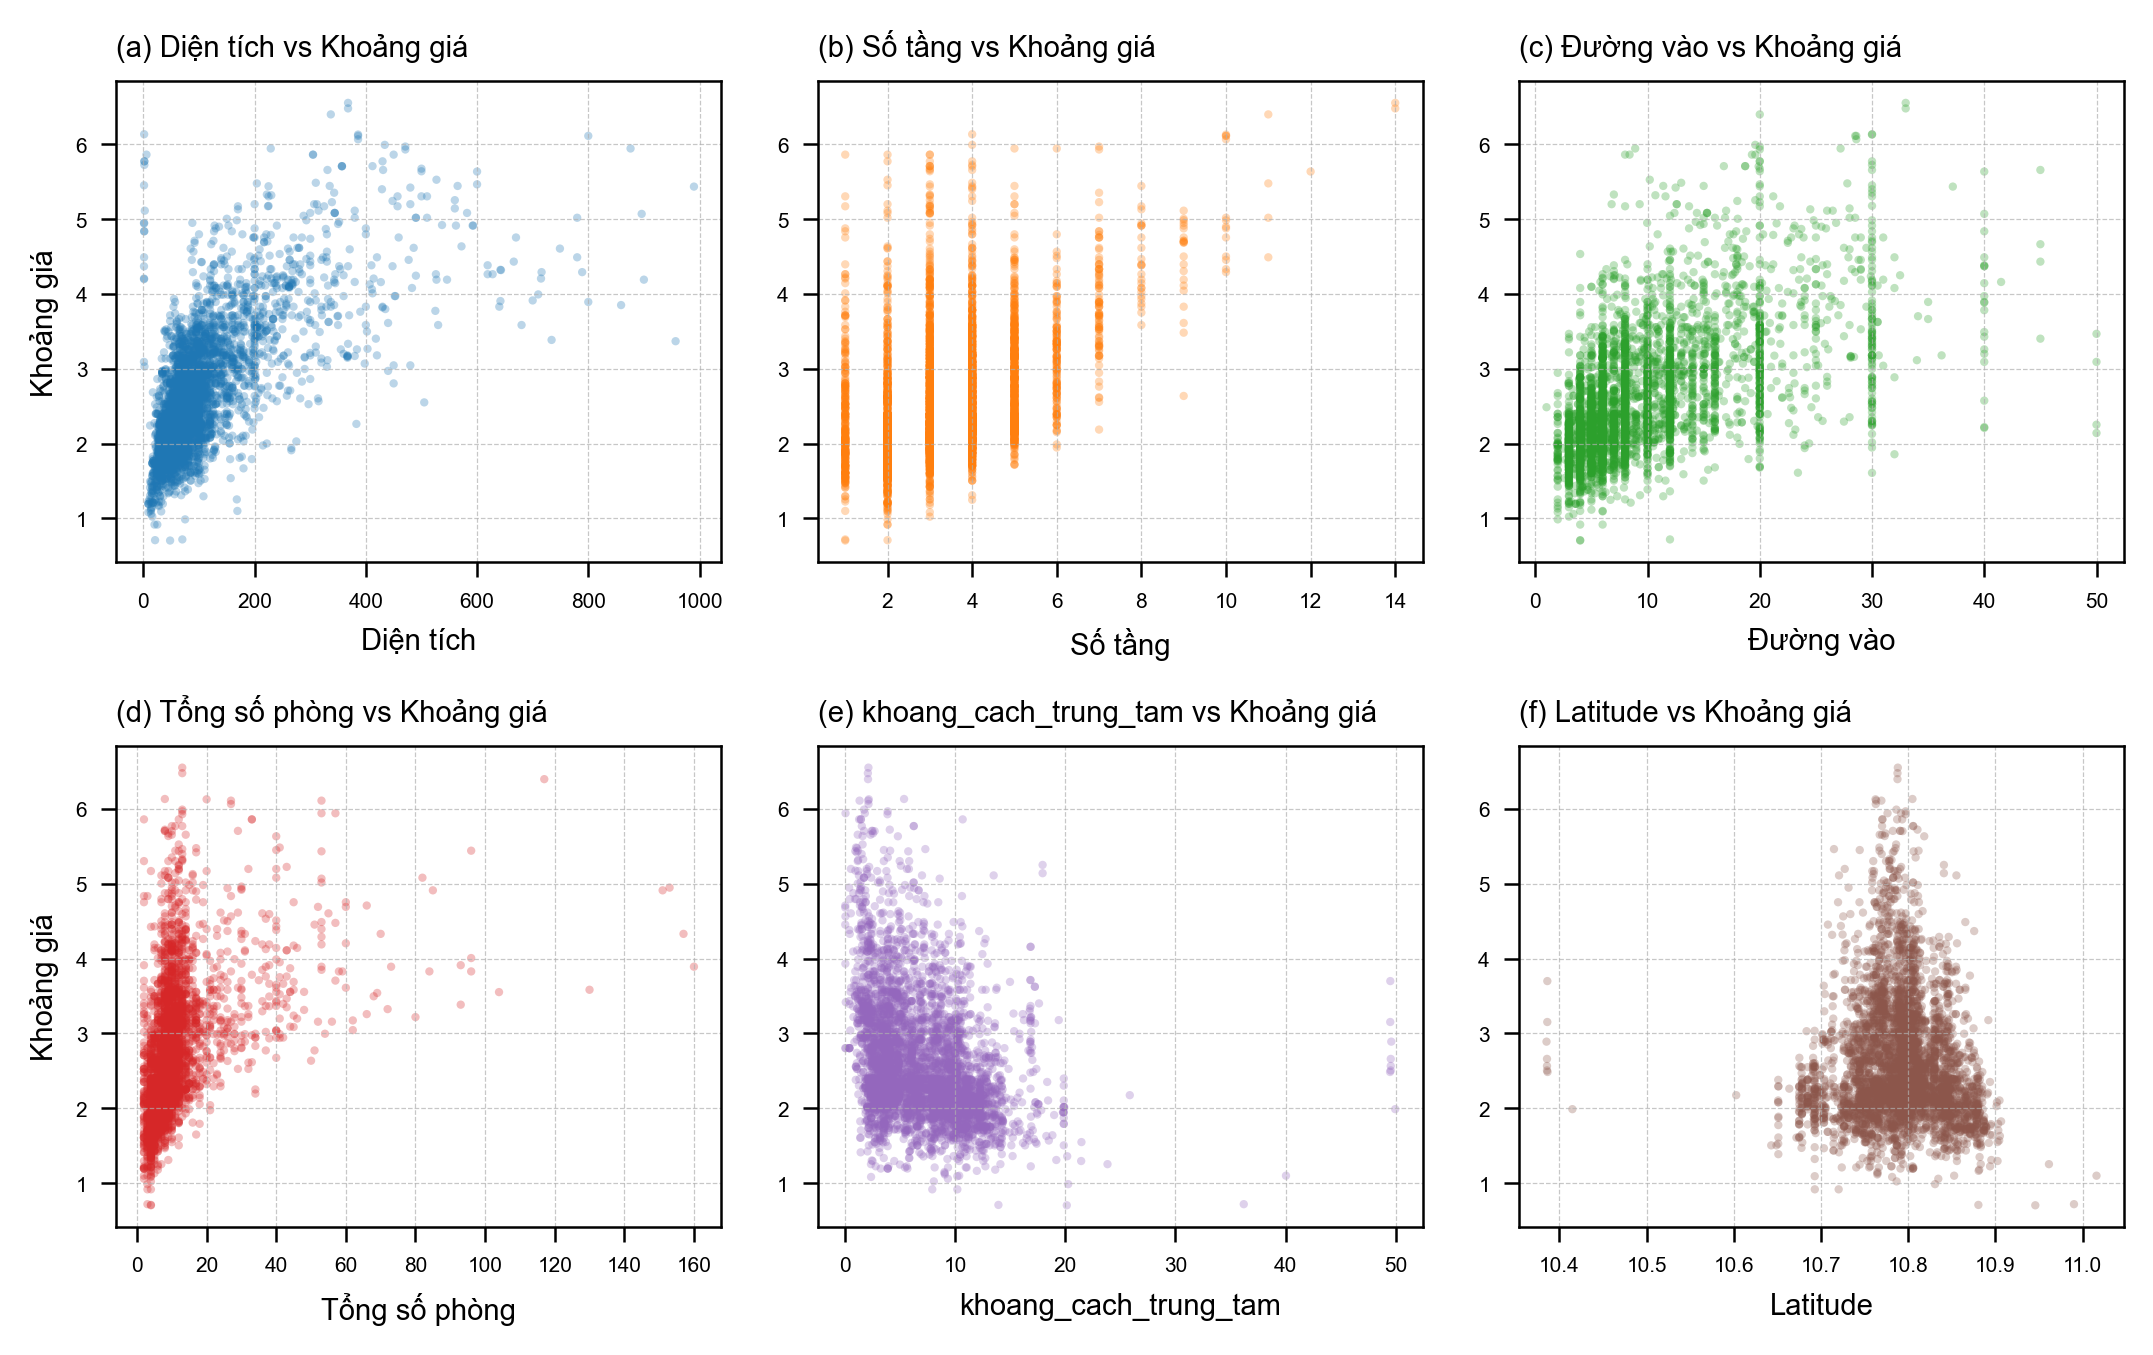

In [ ]:
# ============================================================
# CELL 6 — SCATTER PLOTS: KEY FEATURES VS TARGET
# ============================================================
SCATTER_FEATURES = [
    "Diện tích", "Số tầng", "Đường vào",
    "Tổng số phòng", "khoang_cach_trung_tam", "Latitude",
]

scatter_cols = [c for c in SCATTER_FEATURES if c in df_train.columns]
plot_data = df_train[scatter_cols + [TARGET_COL]].copy()
plot_data = plot_data.apply(pd.to_numeric, errors="coerce").dropna()

assert len(plot_data) > 0, "No valid rows for scatter plots"

SCATTER_COLORS  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]
SCATTER_LABELS  = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

fig, axes = plt.subplots(2, 3, figsize=(7.16, 4.5), dpi=300)
axes = axes.flatten()

for i, feature in enumerate(scatter_cols):
    sns.scatterplot(
        data=plot_data, x=feature, y=TARGET_COL,
        color=SCATTER_COLORS[i], alpha=0.3, edgecolor="none", s=4, ax=axes[i],
    )
    axes[i].set_title(f"{SCATTER_LABELS[i]} {feature} vs {TARGET_COL}", loc="left", pad=6)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(TARGET_COL if i % 3 == 0 else "")
    axes[i].grid(axis="both", linestyle="--", linewidth=0.3, alpha=0.7)

plt.tight_layout(w_pad=2.0, h_pad=1.5)
#plt.savefig("scatter_plots_ieee.png", format="png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Feature Selection: Mutual Information

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/2330511916.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")


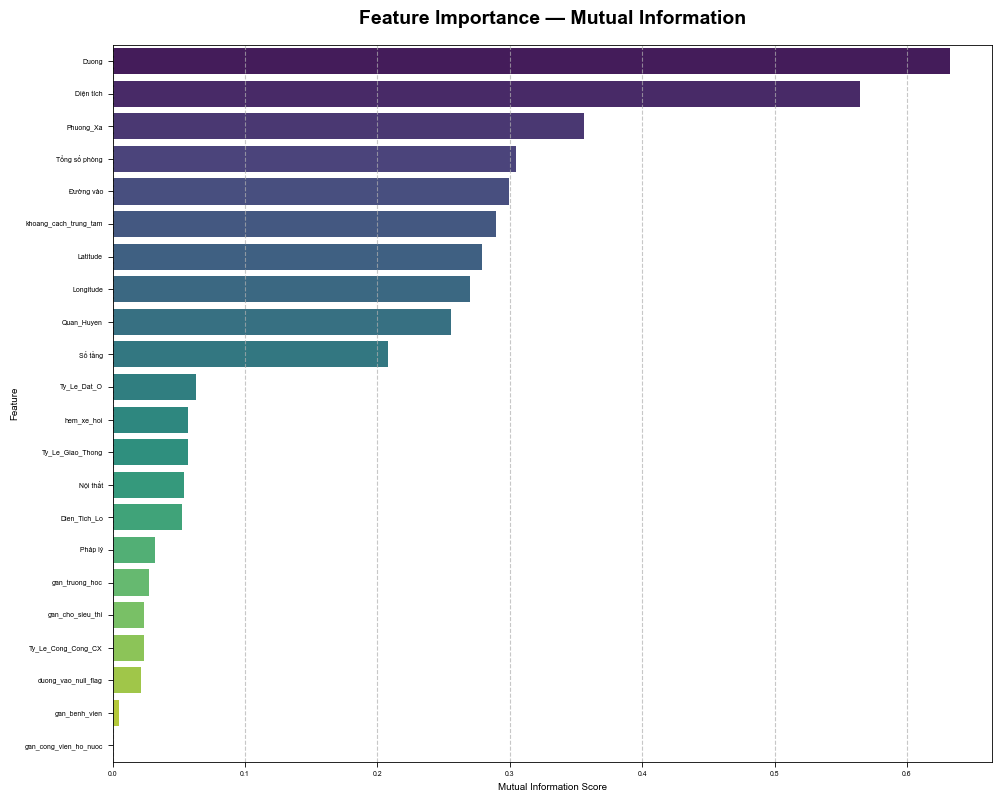

                       MI Score
Duong                    0.6325
Diện tích                0.5645
Phuong_Xa                0.3560
Tổng số phòng            0.3047
Đường vào                0.2990
khoang_cach_trung_tam    0.2894
Latitude                 0.2791
Longitude                0.2697
Quan_Huyen               0.2557
Số tầng                  0.2079
Ty_Le_Dat_O              0.0626
hem_xe_hoi               0.0570
Ty_Le_Giao_Thong         0.0567
Nội thất                 0.0538
Dien_Tich_Lo             0.0520
Pháp lý                  0.0318
gan_truong_hoc           0.0274
gan_cho_sieu_thi         0.0237
Ty_Le_Cong_Cong_CX       0.0236
duong_vao_null_flag      0.0215
gan_benh_vien            0.0045
gan_cong_vien_ho_nuoc    0.0005


In [7]:
# ============================================================
# CELL 7 — FEATURE SELECTION: MUTUAL INFORMATION
# ============================================================
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

COLS_TO_DROP = ["Số phòng ngủ", "Số phòng tắm, vệ sinh", "Ty_Le_Khac"]
cols_to_drop_existing = [c for c in COLS_TO_DROP if c in df_train.columns]

X_mi = df_train.drop(columns=[TARGET_COL] + cols_to_drop_existing).copy()
y_mi = pd.to_numeric(df_train[TARGET_COL], errors="coerce")

for col in X_mi.select_dtypes(include="number").columns:
    X_mi[col] = X_mi[col].fillna(X_mi[col].median())

for col in X_mi.select_dtypes(include=["object", "category"]).columns:
    X_mi[col] = X_mi[col].fillna("Unknown")
    X_mi[col] = LabelEncoder().fit_transform(X_mi[col])

discrete_mask = X_mi.dtypes == int
mi_scores = mutual_info_regression(X_mi, y_mi, discrete_features=discrete_mask, random_state=42)
mi_series = pd.Series(mi_scores, index=X_mi.columns, name="MI Score").sort_values(ascending=False)

assert len(mi_series) > 0, "MI scores are empty"

plt.figure(figsize=(10, 8))
sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")
plt.title("Feature Importance — Mutual Information", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print(mi_series.to_frame().round(4).to_string())

## 8. Feature Selection: Random Forest Importance

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/3364282056.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_series.values, y=rf_series.index, palette="mako")


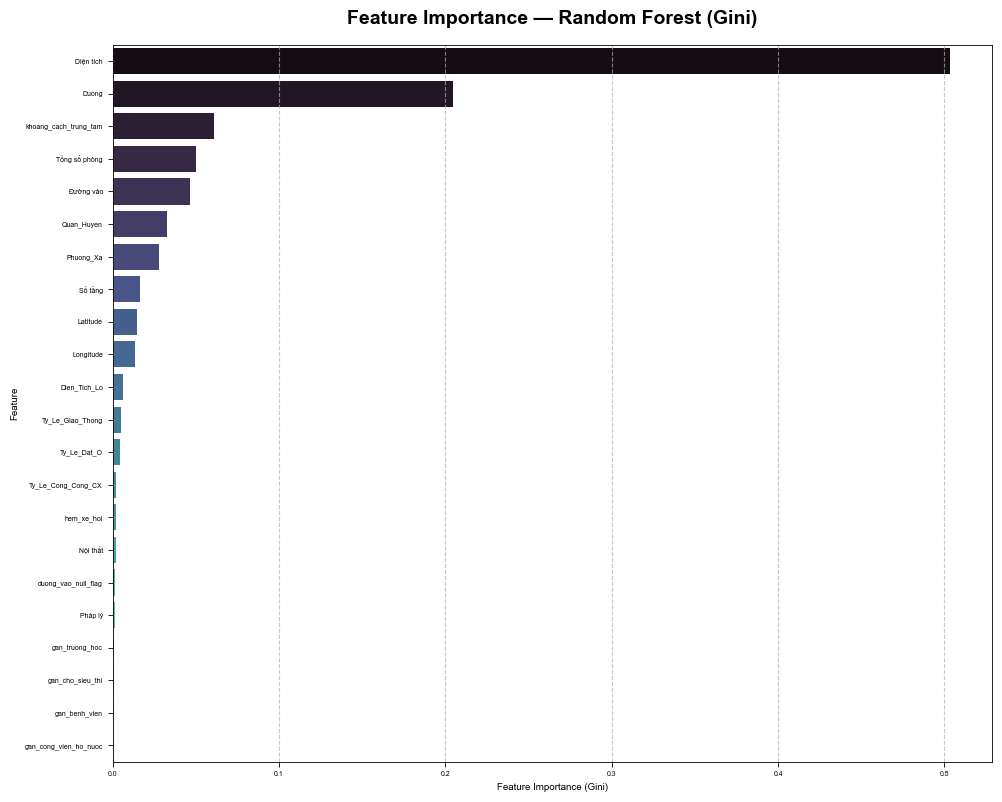

                       RF Importance
Diện tích                     0.5034
Duong                         0.2048
khoang_cach_trung_tam         0.0610
Tổng số phòng                 0.0504
Đường vào                     0.0464
Quan_Huyen                    0.0329
Phuong_Xa                     0.0280
Số tầng                       0.0164
Latitude                      0.0145
Longitude                     0.0137
Dien_Tich_Lo                  0.0064
Ty_Le_Giao_Thong              0.0053
Ty_Le_Dat_O                   0.0045
Ty_Le_Cong_Cong_CX            0.0021
hem_xe_hoi                    0.0019
Nội thất                      0.0019
duong_vao_null_flag           0.0016
Pháp lý                       0.0015
gan_truong_hoc                0.0010
gan_cho_sieu_thi              0.0010
gan_benh_vien                 0.0008
gan_cong_vien_ho_nuoc         0.0007

[WARN] Features with importance < 1% (consider dropping): ['Dien_Tich_Lo', 'Ty_Le_Giao_Thong', 'Ty_Le_Dat_O', 'Ty_Le_Cong_Cong_CX', 'hem_xe_hoi', 'N

In [8]:
# ============================================================
# CELL 8 — FEATURE SELECTION: RANDOM FOREST IMPORTANCE
# ============================================================
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_mi, y_mi)

rf_series = (
    pd.Series(rf_model.feature_importances_, index=X_mi.columns, name="RF Importance")
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))
sns.barplot(x=rf_series.values, y=rf_series.index, palette="mako")
plt.title("Feature Importance — Random Forest (Gini)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Feature Importance (Gini)")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print(rf_series.to_frame().round(4).to_string())

low_importance = rf_series[rf_series < 0.01].index.tolist()
if low_importance:
    print(f"\n[WARN] Features with importance < 1% (consider dropping): {low_importance}")
else:
    print("\n[OK] All features contribute >= 1% to the model.")

## 9. Feature Selection: XGBoost & LightGBM Importance

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/2889504407.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_series.values, y=xgb_series.index, ax=axes[0], palette="OrRd_r")
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/2889504407.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lgb_series.values, y=lgb_series.index, ax=axes[1], palette="YlGnBu_r")


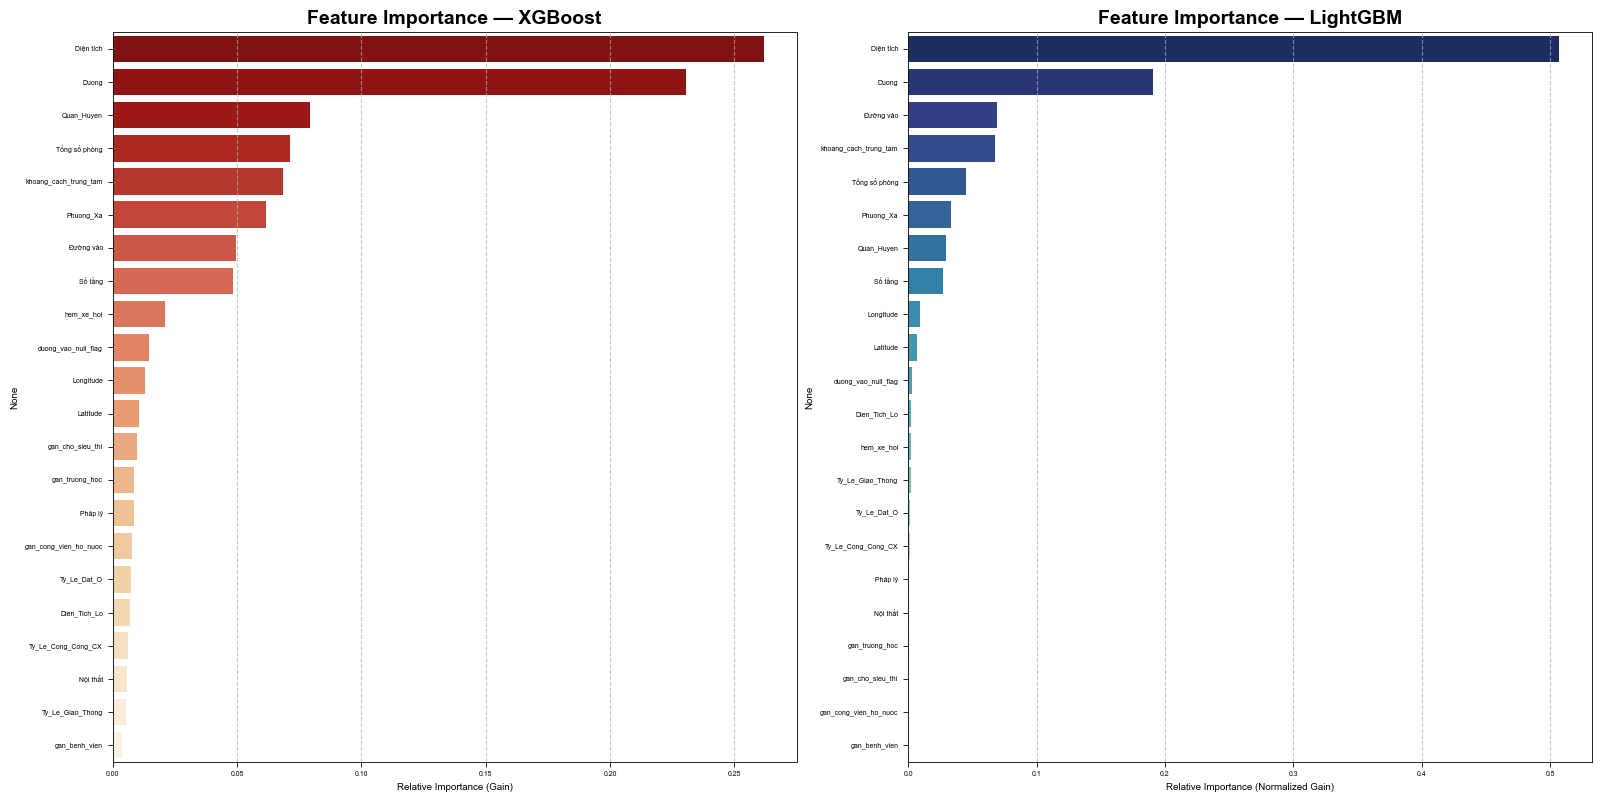

                       XGBoost  LightGBM
Diện tích               0.2619    0.5072
Duong                   0.2303    0.1905
Quan_Huyen              0.0792    0.0293
Tổng số phòng           0.0715    0.0453
khoang_cach_trung_tam   0.0686    0.0680
Phuong_Xa               0.0616    0.0330
Đường vào               0.0498    0.0693
Số tầng                 0.0484    0.0268
hem_xe_hoi              0.0211    0.0020
duong_vao_null_flag     0.0144    0.0029
Longitude               0.0131    0.0092
Latitude                0.0106    0.0069
gan_cho_sieu_thi        0.0097    0.0002
gan_truong_hoc          0.0086    0.0004
Pháp lý                 0.0084    0.0009
gan_cong_vien_ho_nuoc   0.0078    0.0001
Ty_Le_Dat_O             0.0072    0.0014
Dien_Tich_Lo            0.0068    0.0024
Ty_Le_Cong_Cong_CX      0.0062    0.0011
Nội thất                0.0056    0.0009
Ty_Le_Giao_Thong        0.0056    0.0020
gan_benh_vien           0.0036    0.0001


In [9]:
# ============================================================
# CELL 9 — FEATURE SELECTION: XGBOOST & LIGHTGBM IMPORTANCE
# ============================================================
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

xgb_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
xgb_model.fit(X_mi, y_mi)
xgb_series = (
    pd.Series(xgb_model.feature_importances_, index=X_mi.columns, name="XGBoost")
    .sort_values(ascending=False)
)

lgb_model = LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1,
                           importance_type="gain", verbose=-1)
lgb_model.fit(X_mi, y_mi)
lgb_raw = lgb_model.feature_importances_
lgb_series = (
    pd.Series(lgb_raw / lgb_raw.sum(), index=X_mi.columns, name="LightGBM")
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
sns.barplot(x=xgb_series.values, y=xgb_series.index, ax=axes[0], palette="OrRd_r")
axes[0].set_title("Feature Importance — XGBoost", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Relative Importance (Gain)")
axes[0].grid(axis="x", linestyle="--", alpha=0.7)

sns.barplot(x=lgb_series.values, y=lgb_series.index, ax=axes[1], palette="YlGnBu_r")
axes[1].set_title("Feature Importance — LightGBM", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Relative Importance (Normalized Gain)")
axes[1].grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

comparison_df = (
    pd.DataFrame({"XGBoost": xgb_series, "LightGBM": lgb_series})
    .fillna(0)
    .sort_values("XGBoost", ascending=False)
)
print(comparison_df.round(4).to_string())

## 10. Land-Use Scatter (Dien_Tich_Lo vs Rate Columns)

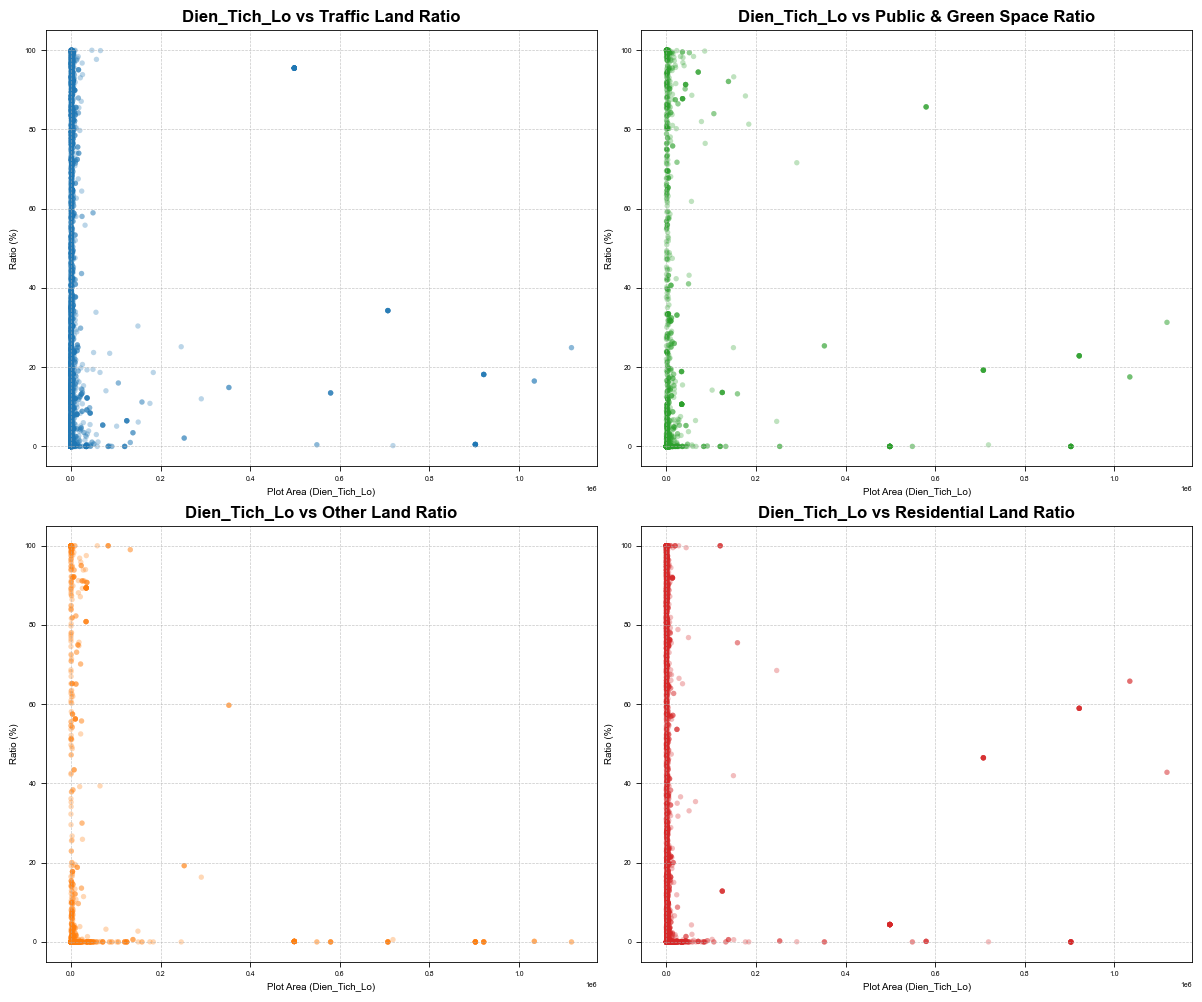

In [10]:
# ============================================================
# CELL 10 — LAND USE SCATTER: Dien_Tich_Lo vs RATE COLUMNS
# ============================================================
X_VAR   = "Dien_Tich_Lo"
Y_VARS  = ["Ty_Le_Giao_Thong", "Ty_Le_Cong_Cong_CX", "Ty_Le_Khac", "Ty_Le_Dat_O"]
Y_VARS  = [c for c in Y_VARS if c in df_train.columns]

LAND_COLORS = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"]
LAND_TITLES = [
    "Traffic Land Ratio",
    "Public & Green Space Ratio",
    "Other Land Ratio",
    "Residential Land Ratio",
]

if X_VAR in df_train.columns and Y_VARS:
    land_plot = df_train[[X_VAR] + Y_VARS].copy()
    land_plot = land_plot.apply(pd.to_numeric, errors="coerce").dropna()

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, y_col in enumerate(Y_VARS):
        sns.scatterplot(
            data=land_plot, x=X_VAR, y=y_col,
            color=LAND_COLORS[i], alpha=0.3, edgecolor="none", s=15, ax=axes[i],
        )
        axes[i].set_title(f"{X_VAR} vs {LAND_TITLES[i]}", fontsize=12, fontweight="bold")
        axes[i].set_xlabel("Plot Area (Dien_Tich_Lo)")
        y_label = "Ratio (%)" if land_plot[y_col].max() > 1.5 else "Ratio (0.0 – 1.0)"
        axes[i].set_ylabel(y_label)
        axes[i].grid(axis="both", linestyle="--", linewidth=0.5, alpha=0.7)

    plt.tight_layout()
    plt.show()

## 11. Categorical Features vs Target (Boxplots)

/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/886387175.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/886387175.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/886387175.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/886387175.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

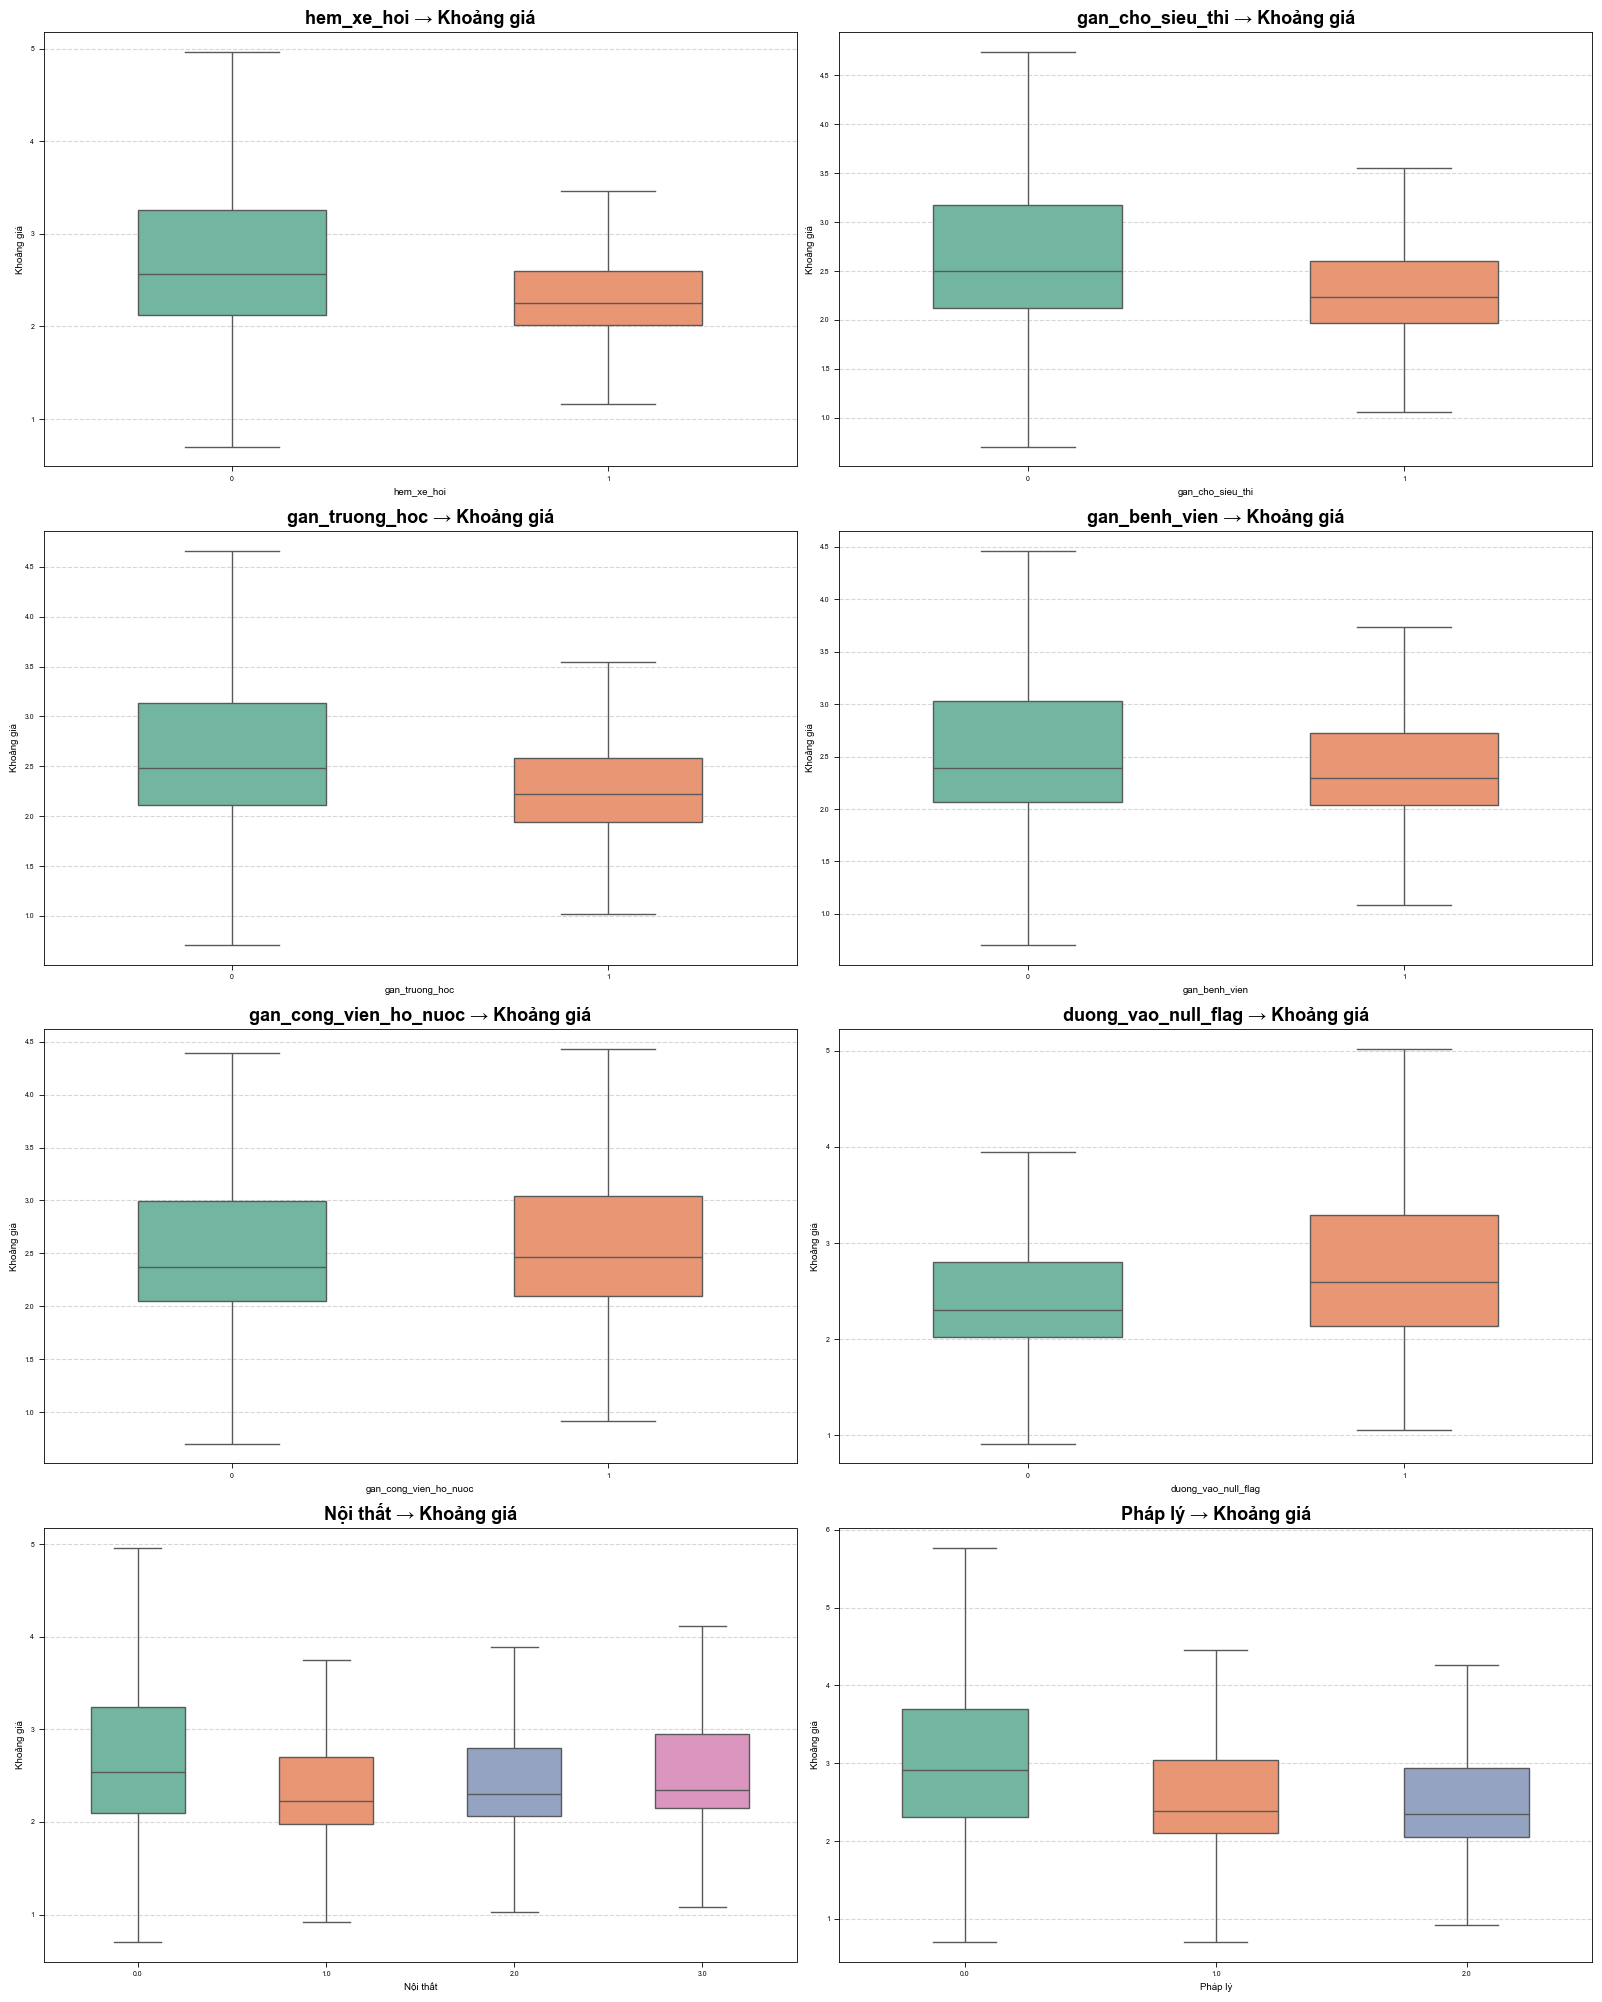

In [11]:
# ============================================================
# CELL 11 — BOXPLOTS: CATEGORICAL FEATURES VS TARGET
# ============================================================
CAT_FEATURES = [
    "hem_xe_hoi", "gan_cho_sieu_thi", "gan_truong_hoc",
    "gan_benh_vien", "gan_cong_vien_ho_nuoc",
    "duong_vao_null_flag", "Nội thất", "Pháp lý",
]
valid_cat_features = [c for c in CAT_FEATURES if c in df_train.columns]

df_train[TARGET_COL] = pd.to_numeric(df_train[TARGET_COL], errors="coerce")

if valid_cat_features:
    n_cols = 2
    n_rows = int(np.ceil(len(valid_cat_features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(valid_cat_features):
        sns.boxplot(
            data=df_train, x=col, y=TARGET_COL,
            ax=axes[i], palette="Set2", width=0.5, showfliers=False,
        )
        axes[i].set_title(f"{col} → {TARGET_COL}", fontsize=13, fontweight="bold")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(TARGET_COL)
        axes[i].grid(axis="y", linestyle="--", alpha=0.5)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

## 12. Drop Redundant Columns

In [12]:
# ============================================================
# CELL 12 — DROP REDUNDANT COLUMNS
# ============================================================
DROP_COLS = ["Số phòng ngủ", "Số phòng tắm, vệ sinh", "Ty_Le_Khac"]
drop_existing = [c for c in DROP_COLS if c in df_train.columns]

df_train = df_train.drop(columns=drop_existing)
df_test  = df_test.drop(columns=[c for c in drop_existing if c in df_test.columns])

print(f"Dropped columns: {drop_existing}")
print(f"Train shape after drop: {df_train.shape}")
print(f"Test  shape after drop: {df_test.shape}")

Dropped columns: ['Số phòng ngủ', 'Số phòng tắm, vệ sinh', 'Ty_Le_Khac']
Train shape after drop: (4645, 23)
Test  shape after drop: (1164, 23)


## 13. Numeric Feature Impact Summary

              Feature  Correlation  Price_Ratio_Q4Q1  Impact_%  Count
            Diện tích       0.6647            1.6657     66.57   4645
            Đường vào       0.5778            1.6154     61.54   4645
                Duong       0.5587            1.5674     56.74   4645
            Phuong_Xa       0.4838            1.4752     47.52   4645
              Số tầng       0.4499            1.4148     41.48   4645
        Tổng số phòng       0.4421            1.5615     56.15   4645
           Quan_Huyen       0.4348            1.4452     44.52   4645
khoang_cach_trung_tam      -0.3191            0.7571    -24.29   4645
            Longitude       0.1416            1.1357     13.57   4645
         Dien_Tich_Lo       0.1081            1.0200      2.00   3684
             Latitude      -0.0739            0.9308     -6.92   4645
          Ty_Le_Dat_O      -0.0696            0.9343     -6.57   3678
     Ty_Le_Giao_Thong       0.0403            1.0225      2.25   3678


/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/2918745726.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_q = valid[target].groupby(labels).mean()
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/2918745726.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_q = valid[target].groupby(labels).mean()
/var/folders/4m/90s_pcxj0kv8zqdhjxnrmcn80000gn/T/ipykernel_50810/2918745726.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observe

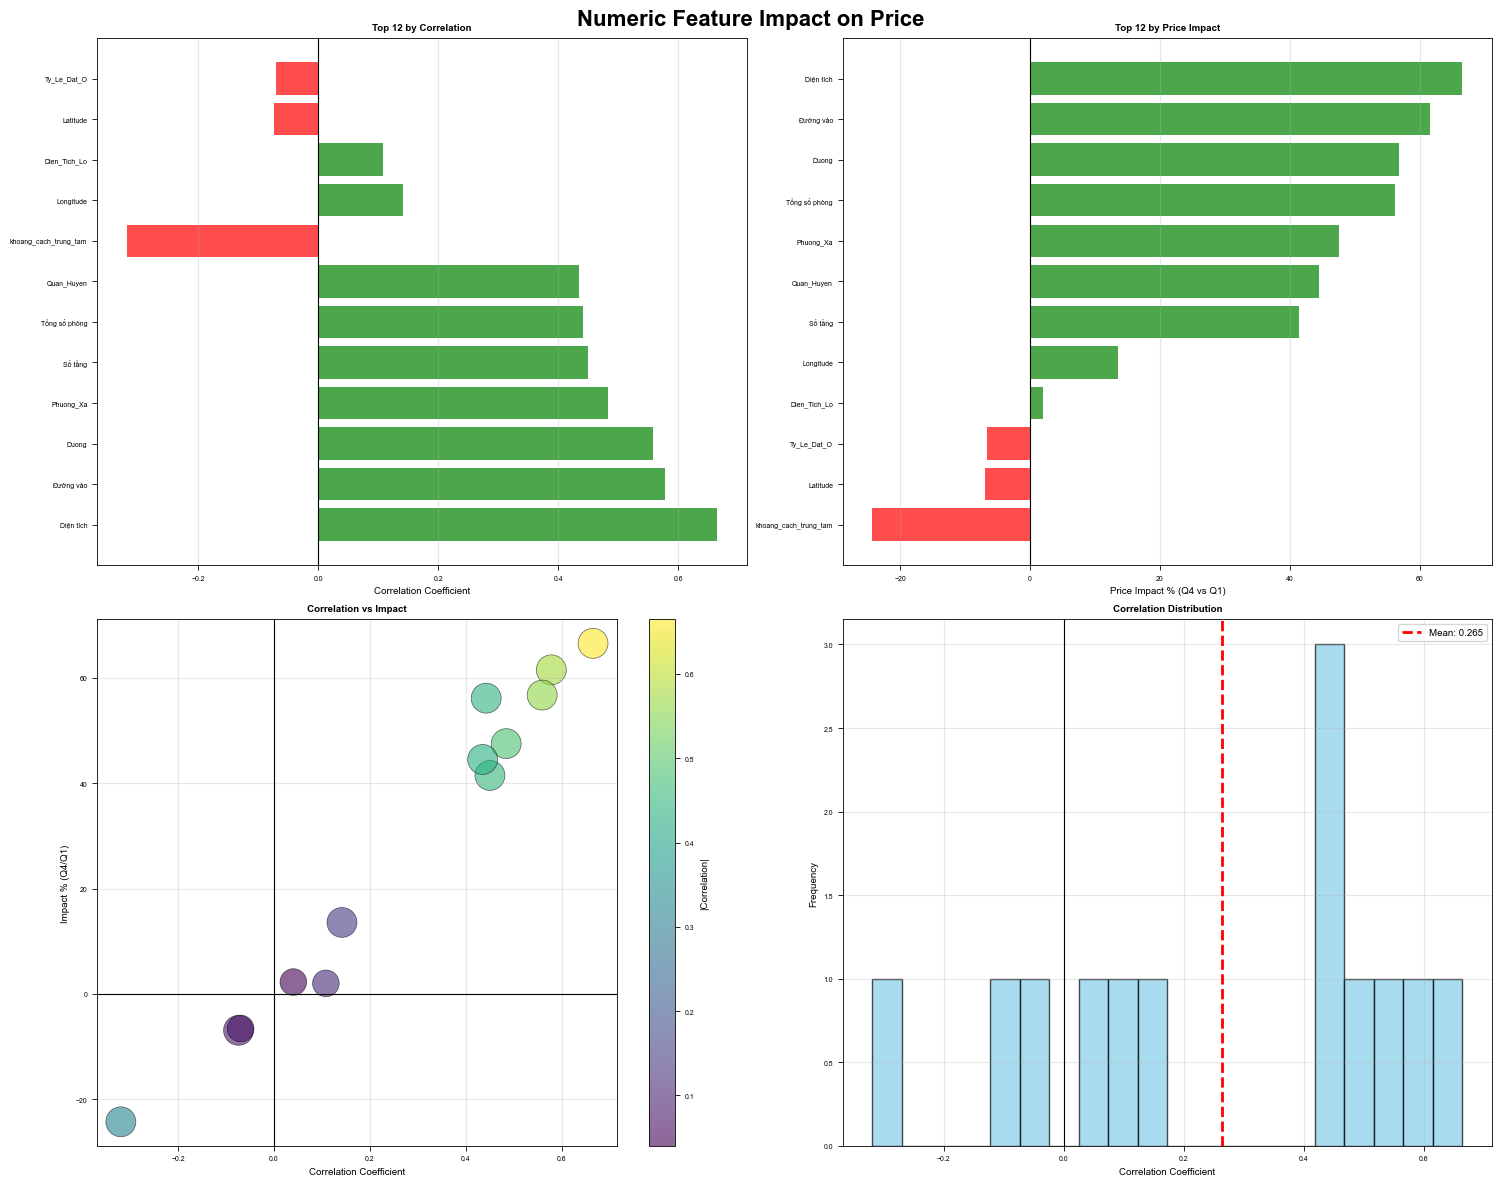


Correlation stats — mean: 0.2646, median: 0.4348, std: 0.3088


In [13]:
# ============================================================
# CELL 13 — NUMERIC FEATURE IMPACT SUMMARY
# ============================================================
def compute_impact_summary(df: pd.DataFrame, target: str) -> pd.DataFrame:
    """Compute correlation and Q4/Q1 price ratio for every numeric feature."""
    numeric_cols = df.select_dtypes(include=np.number).columns.difference([target])
    records = []

    for col in numeric_cols:
        valid = df[[col, target]].dropna()
        if valid.empty:
            continue
        try:
            corr = valid[col].corr(valid[target])
            labels = pd.qcut(valid[col], q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
            price_by_q = valid[target].groupby(labels).mean()
            ratio = (price_by_q.get("Q4", np.nan) / price_by_q.get("Q1", np.nan)
                     if price_by_q.get("Q1", 0) > 0 else np.nan)
            records.append({
                "Feature":          col,
                "Correlation":      round(corr, 4),
                "Price_Ratio_Q4Q1": round(ratio, 4) if pd.notna(ratio) else np.nan,
                "Impact_%":         round((ratio - 1) * 100, 2) if pd.notna(ratio) else np.nan,
                "Count":            len(valid),
            })
        except Exception:
            continue

    result = pd.DataFrame(records)
    result["Abs_Corr"] = result["Correlation"].abs()
    return result.sort_values("Abs_Corr", ascending=False).reset_index(drop=True)


impact_df = compute_impact_summary(df_train, TARGET_COL)

assert not impact_df.empty, "Impact summary is empty — check that numeric columns exist"

print(impact_df[["Feature", "Correlation", "Price_Ratio_Q4Q1", "Impact_%", "Count"]].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Numeric Feature Impact on Price", fontsize=16, fontweight="bold")

top12 = impact_df.head(12)

bar_colors = ["green" if v > 0 else "red" for v in top12["Correlation"]]
axes[0, 0].barh(range(len(top12)), top12["Correlation"], color=bar_colors, alpha=0.7)
axes[0, 0].set_yticks(range(len(top12)))
axes[0, 0].set_yticklabels(top12["Feature"])
axes[0, 0].set_xlabel("Correlation Coefficient")
axes[0, 0].set_title("Top 12 by Correlation", fontweight="bold")
axes[0, 0].axvline(0, color="black", linewidth=0.8)
axes[0, 0].grid(axis="x", alpha=0.3)

impact_top = top12.sort_values("Impact_%")
bar_colors2 = ["green" if v > 0 else "red" for v in impact_top["Impact_%"]]
axes[0, 1].barh(range(len(impact_top)), impact_top["Impact_%"], color=bar_colors2, alpha=0.7)
axes[0, 1].set_yticks(range(len(impact_top)))
axes[0, 1].set_yticklabels(impact_top["Feature"])
axes[0, 1].set_xlabel("Price Impact % (Q4 vs Q1)")
axes[0, 1].set_title("Top 12 by Price Impact", fontweight="bold")
axes[0, 1].axvline(0, color="black", linewidth=0.8)
axes[0, 1].grid(axis="x", alpha=0.3)

sc = axes[1, 0].scatter(
    impact_df["Correlation"], impact_df["Impact_%"],
    s=impact_df["Count"] / 10, alpha=0.6,
    c=impact_df["Abs_Corr"], cmap="viridis", edgecolors="black", linewidth=0.5,
)
axes[1, 0].set_xlabel("Correlation Coefficient")
axes[1, 0].set_ylabel("Impact % (Q4/Q1)")
axes[1, 0].set_title("Correlation vs Impact", fontweight="bold")
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].axhline(0, color="black", linewidth=0.8)
axes[1, 0].axvline(0, color="black", linewidth=0.8)
plt.colorbar(sc, ax=axes[1, 0], label="|Correlation|")

mean_corr = impact_df["Correlation"].mean()
axes[1, 1].hist(impact_df["Correlation"], bins=20, color="skyblue", edgecolor="black", alpha=0.7)
axes[1, 1].axvline(mean_corr, color="red", linestyle="--", linewidth=2,
                   label=f"Mean: {mean_corr:.3f}")
axes[1, 1].axvline(0, color="black", linewidth=0.8)
axes[1, 1].set_xlabel("Correlation Coefficient")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].set_title("Correlation Distribution", fontweight="bold")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCorrelation stats — mean: {mean_corr:.4f}, "
      f"median: {impact_df['Correlation'].median():.4f}, "
      f"std: {impact_df['Correlation'].std():.4f}")

## 14. Supply vs Price Volatility by District

Spearman: listing_count vs median_price = 0.254
Spearman: listing_count vs price_std    = 0.303


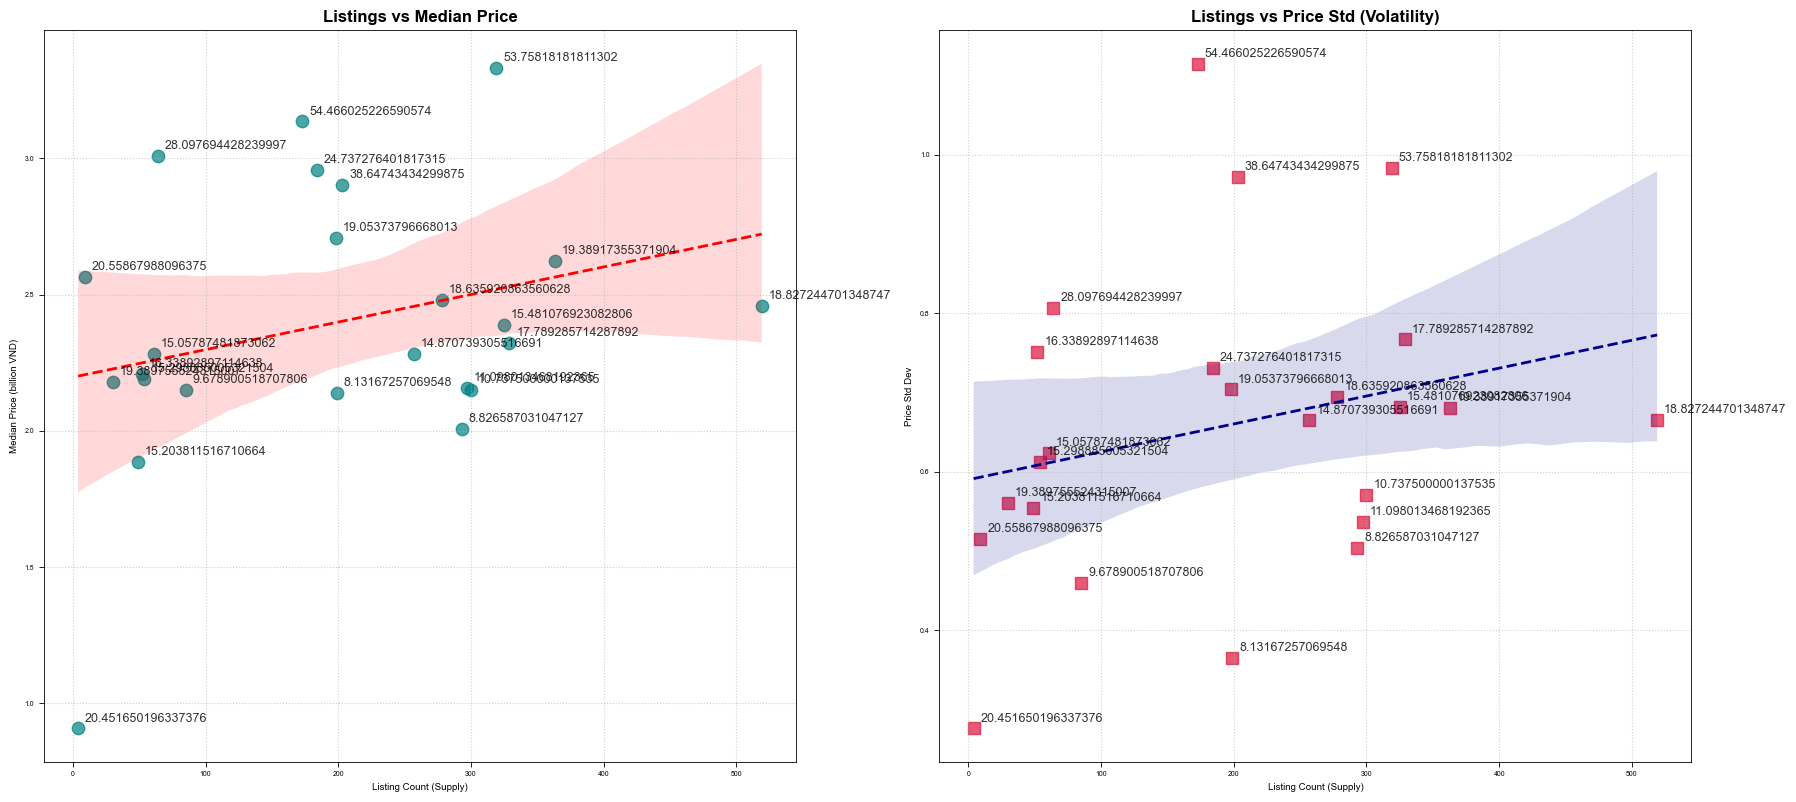

In [14]:
# ============================================================
# CELL 14 — SUPPLY vs PRICE VOLATILITY BY DISTRICT
# ============================================================
DISTRICT_COL = "Quan_Huyen"

if DISTRICT_COL in df_train.columns:
    market_df = (
        df_train.groupby(DISTRICT_COL)[TARGET_COL]
        .agg(
            listing_count="count",
            median_price="median",
            price_std="std",
            price_iqr=lambda x: x.quantile(0.75) - x.quantile(0.25),
        )
        .reset_index()
        .fillna(0)
    )

    corr_vol_price = market_df["listing_count"].corr(market_df["median_price"], method="spearman")
    corr_vol_std   = market_df["listing_count"].corr(market_df["price_std"],   method="spearman")
    print(f"Spearman: listing_count vs median_price = {corr_vol_price:.3f}")
    print(f"Spearman: listing_count vs price_std    = {corr_vol_std:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    for ax, y_col, color, marker, title, y_label in [
        (axes[0], "median_price", "teal",    "o", "Listings vs Median Price",        "Median Price (billion VND)"),
        (axes[1], "price_std",    "crimson", "s", "Listings vs Price Std (Volatility)", "Price Std Dev"),
    ]:
        sns.regplot(
            data=market_df, x="listing_count", y=y_col, ax=ax, color=color, marker=marker,
            scatter_kws={"s": 80, "alpha": 0.7},
            line_kws={"color": "red" if color == "teal" else "darkblue",
                      "linewidth": 2, "linestyle": "--"},
        )
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Listing Count (Supply)")
        ax.set_ylabel(y_label)
        ax.grid(True, linestyle=":", alpha=0.6)

        for _, row in market_df.iterrows():
            ax.annotate(row[DISTRICT_COL], (row["listing_count"], row[y_col]),
                        textcoords="offset points", xytext=(5, 5),
                        ha="left", fontsize=9, alpha=0.8)

    plt.tight_layout()
    plt.show()

## 15. Save Processed Data

In [15]:
# ============================================================
# CELL 15 — SAVE PROCESSED DATA
# ============================================================
df_train.to_csv(TRAIN_PATH, index=False, encoding="utf-8-sig")
df_test.to_csv(TEST_PATH,  index=False, encoding="utf-8-sig")

train_mb = os.path.getsize(TRAIN_PATH) / (1024 ** 2)
test_mb  = os.path.getsize(TEST_PATH)  / (1024 ** 2)

assert train_mb > 0, "Train file was not saved correctly"
assert test_mb  > 0, "Test file was not saved correctly"

print(f"Saved train → {TRAIN_PATH} ({train_mb:.2f} MB)")
print(f"Saved test  → {TEST_PATH}  ({test_mb:.2f} MB)")

Saved train → data_output/2_data_preprocessed_tree_train.csv (0.89 MB)
Saved test  → data_output/2_data_preprocessed_tree_test.csv  (0.22 MB)
